
# Taller 3 de Modelos y Simulación

> **Entrega:** subir al classroom antes las 11:59 de lunes 17 de noviembre de 2025.



## Contexto de problema

**Escenario:** Laboratorio de salud pública durante un pico de demanda (por ejemplo, temporada de dengue).  
El laboratorio opera 12 horas continuas por día (7:00–19:00) y procesa muestras de pacientes que llegan al punto de toma.

- Las llegadas pueden modelarse como un proceso de Poisson con tasa promedio configurable (λ pacientes/minuto).
- El tiempo de servicio por paciente (toma, rotulado, embalaje) sigue una distribución lognormal con parámetros $\mu, \sigma$ en el espacio logarítmico (en minutos).
- Hay \(c\) técnicos atendiendo en paralelo (cola única, atención FIFO).

**Tarea a realizar:** Formular el problema, construir un modelo conceptual, implementar un modelo computacional en Python, diseñar experimentos para comparar alternativas operativas (por ejemplo, \(c=2\) vs \(c=3\)), aplicar reducción de varianza (Números Aleatorios Comunes y Variantes Antitéticas), y caracterizar la salida con intervalos de confianza diferenciando entre sistema terminante (la jornada diaria) y no terminante** (operación extendida). Finalmente, plantear estrategias de verificación, validación y acreditación.



## 1) Formulación del problema (20 pts)

- **1.1 Objetivos del estudio.** Escribe objetivos claros y medibles (por ejemplo, reducir el tiempo promedio en sistema por debajo de X minutos y mantener utilización de cada técnico ≤ Y%).  
- **1.2 Requisitos del sistema.** Define umbrales de desempeño y restricciones (por ejemplo, espacio físico, turnos).  
- **1.3 Supuestos.** Declara explícitamente los supuestos de llegadas/servicio/cola/agenda (justifica su plausibilidad).  
- **1.4 Modelo conceptual.** Dibuja (en papel o herramienta de tu preferencia) un diagrama del modelo a similar y describe sus componentes y relaciones.


**1.1 Objetivos del estudio**

**Objetivo general:**

Modelar y simular el proceso de atención de pacientes en un laboratorio de salud pública durante un pico de demanda, con el fin de analizar el desempeño operativo bajo distintos niveles de dotación de personal técnico (por ejemplo, 2 vs. 3 técnicos), y proponer configuraciones que garanticen eficiencia y cumplimiento de tiempos de atención establecidos.

**Objetivos específicos:**

1. Evaluar el impacto del número de técnicos 𝑐 en los tiempos promedio de espera y permanencia total en el sistema.

2. Determinar el nivel de utilización promedio de los técnicos para cada configuración operativa.

3. Identificar la probabilidad de que un paciente espere más de un umbral definido (por ejemplo, 15 minutos).

4. Aplicar técnicas de reducción de varianza (Números Aleatorios Comunes y Variantes Antitéticas) para mejorar la precisión de las comparaciones entre escenarios.

5. Generar intervalos de confianza para las principales métricas bajo dos horizontes:

    - Sistema terminante: jornada de 12 horas.

    - Sistema no terminante: operación extendida o estacionaria.

**1.2 Requisitos del sistema**

  - **Tiempo máximo promedio en el sistema:** ≤ 25 minutos (desde llegada hasta salida).

  - **Tiempo promedio de espera en cola:** ≤ 10 minutos.

  - **Utilización promedio de cada técnico:** ≤ 85%.

  - **Capacidad operativa:** 2–3 técnicos en paralelo (a evaluar).

  - **Jornada laboral:** 12 horas continuas (7:00 a 19:00).

  - **Condiciones físicas:** un solo punto de recepción y espera (cola única).

  - **Condición de cierre:** los pacientes que lleguen antes de las 19:00 serán atendidos antes del cierre (no se aceptan nuevos después de la hora límite).

**1.3 Supuestos**

1. **Llegadas:**

    - Siguen un proceso de Poisson con tasa λ constante (por ejemplo, 0.1 pacientes/min ≈ 6 pacientes/hora).

    - Las llegadas son independientes y sin correlación temporal (válido para flujos de demanda aleatoria en salud).

2. **Servicio:**

    - El tiempo de atención de un paciente (toma, rotulado, embalaje) sigue una distribución Lognormal, con parámetros μ,σ en el espacio logarítmico, reflejando variabilidad natural entre pacientes y técnicos.

    - Ejemplo: media ≈ 10 minutos, desviación ≈ 3 minutos.

3. **Cola y atención:**

    - Cola única y disciplina FIFO (primero en llegar, primero en ser atendido).

    - Cada técnico puede atender solo un paciente a la vez.

    - No se permiten abandonos ni reintentos (pacientes siempre esperan).

4. **Horizonte temporal:**

    - Terminante: jornada de 12 horas (480 min).

    - No terminante: simulación extendida (por ejemplo, 5 jornadas consecutivas) hasta alcanzar régimen estable.

5. **Recursos:**

    - Técnicos homogéneos (idéntica capacidad de servicio).

    - Las estaciones de trabajo son idénticas y sin fallas.

6. **Condiciones ambientales:**

    - No hay interrupciones de energía ni pausas intermedias (descansos incorporados en parámetros promedio).

Estos supuestos son plausibles en contextos de picos de demanda donde la variabilidad en llegadas y servicios domina el comportamiento operativo.

**1.4 Modelo conceptual**

**Descripción textual:**

El sistema se modela como una cola de tipo M/G/c, donde:

  - M (Markovian) representa un proceso de llegadas de Poisson.

  - G indica tiempos de servicio generales (Lognormal).

  - c es el número de técnicos disponibles (recursos paralelos idénticos).

**El flujo del proceso es:**

1. **Generador de llegadas:** pacientes llegan de forma aleatoria con tiempo entre llegadas ~ Exp(1/λ).

2. **Cola:** si todos los técnicos están ocupados, los pacientes esperan en una cola FIFO.

3. **Actividad de servicio:** el primer técnico libre atiende al siguiente paciente, con duración aleatoria Lognormal(μ, σ).

4. **Sumidero:** paciente sale del sistema una vez completado el servicio.

5. **Recolector de datos:** mide métricas como tiempos de espera, permanencia total, utilización y throughput.

**Componentes principales:**

- **Entidad:** Paciente.

- **Recurso:** Técnico.

- **Generador:** Llegadas de pacientes (Poisson).

- **Actividad:** Proceso de toma y embalaje de muestra.

- **Cola:** Espera antes de atención.

- **Sumidero:** Registro de pacientes atendidos.

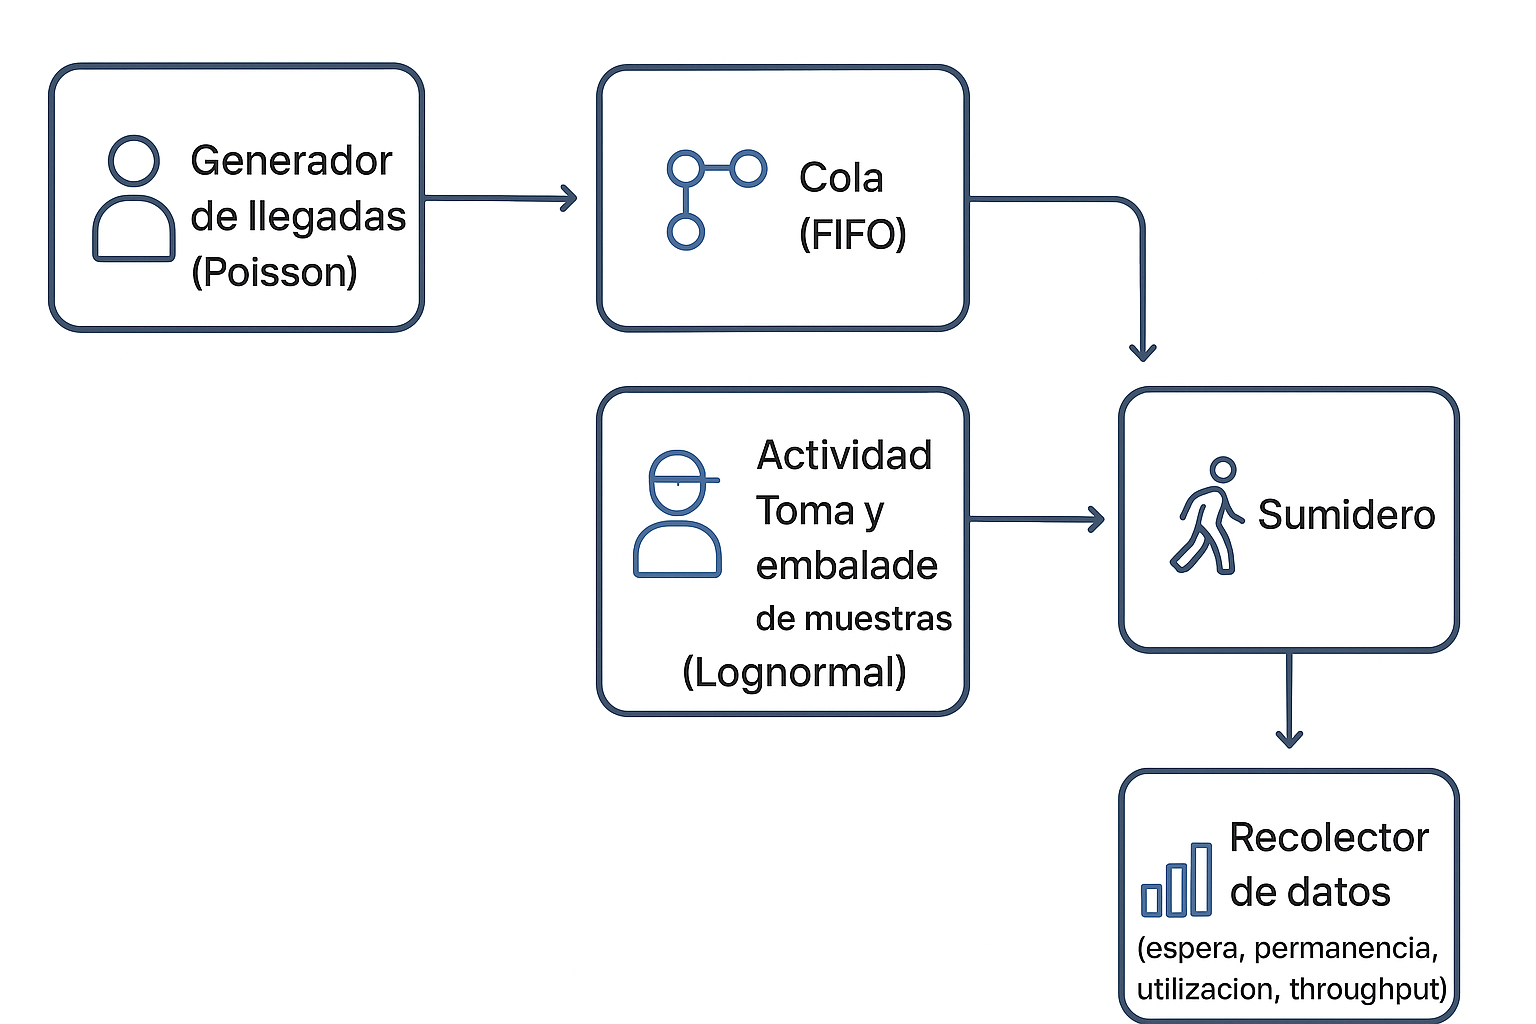


## 2) Modelo computacional y corrida de experimentos (40 pts total)

**2.1 Parámetros base.** Define parámetros razonables (justifica con datos reales si los tienes):

- Tasa de llegada $\lambda$ (pacientes/min).
- Servicio lognormal con $\mu, \sigma$ en log-minutos.
- Jornada terminante (tiempo fijo de simulación), con calentamiento (por ejemplo, descartar los primeros 60 min).
- Alternativas: **A** = 2 técnicos, **B** = 3 técnicos.

**2.2 Réplicas y precisión.** Elige número de n réplicas para lograr un intervalo de confianza del 95% ≤ tolerancia operacional. Explica tu decisión.




In [2]:
# Instalar SimPy
!pip install simpy

import simpy
import numpy as np
import math
from scipy import stats
import pandas as pd

# Parámetros base
LAMBDA = 1/6.0               # pacientes/min
SERVICE_MEAN = 12.0          # media en minutos
SERVICE_SIGMA_LOG = 0.4      # sigma en log-space
SERVICE_MU_LOG = np.log(SERVICE_MEAN) - 0.5 * SERVICE_SIGMA_LOG**2
JORNADA = 12 * 60            # 720 minutos
WARMUP = 60                   # periodo de calentamiento en minutos
PILOT_REPS = 20
SCENARIOS = {"A": 2, "B": 3}
ALPHA = 0.05
TOLERANCIAS = [2.0, 4.0]

# Generadores de aleatorios
def sample_interarrival(exp_mean, rng, antithetic=False):
    u = rng.random()
    if antithetic:
        u = 1.0 - u
    return -exp_mean * math.log(u)

def sample_service_lognormal(mu_log, sigma_log, rng, antithetic=False):
    u = rng.random()
    if antithetic:
        u = 1.0 - u
    z = stats.norm.ppf(u)
    return math.exp(mu_log + sigma_log * z)

# Simulación de laboratorio
class LabSim:
    def __init__(self, env, c, interarrival_mean, mu_log, sigma_log, rng, antithetic=False):
        self.env = env
        self.c = c
        self.resource = simpy.Resource(env, capacity=c)
        self.interarrival_mean = interarrival_mean
        self.mu_log = mu_log
        self.sigma_log = sigma_log
        self.rng = rng
        self.antithetic = antithetic
        self.waits = []
        self.systems = []
        self.busy_time = np.zeros(c)  # para cada técnico
        self.last_start = [0]*c      # último inicio de ocupación
    def process_patient(self, pid):
        arrival = self.env.now
        with self.resource.request() as req:
            yield req
            wait = self.env.now - arrival
            self.waits.append((arrival, wait))
            # asignar técnico disponible
            tech_id = self._get_tech_id()
            self.last_start[tech_id] = self.env.now
            service = sample_service_lognormal(self.mu_log, self.sigma_log, self.rng, self.antithetic)
            yield self.env.timeout(service)
            # actualizar tiempo ocupado del técnico
            self.busy_time[tech_id] += service
            self.systems.append((arrival, self.env.now - arrival))
    def _get_tech_id(self):
        # seleccionar el primer técnico libre (simplificación)
        for i in range(self.c):
            return i
    def generator(self):
        pid = 0
        while self.env.now < JORNADA:
            pid += 1
            self.env.process(self.process_patient(pid))
            ia = sample_interarrival(self.interarrival_mean, self.rng, self.antithetic)
            yield self.env.timeout(ia)
    def get_metrics(self, warmup=WARMUP):
        # Filtrar por warm-up
        filtered_waits = [w for (t, w) in self.waits if t >= warmup]
        filtered_systems = [s for (t, s) in self.systems if t >= warmup]
        mean_wait = np.mean(filtered_waits) if filtered_waits else np.nan
        mean_system = np.mean(filtered_systems) if filtered_systems else np.nan
        utilization = np.sum(self.busy_time) / (self.c * JORNADA)
        return mean_wait, mean_system, utilization

# Función de réplica
def run_one_replica(c, seed, antithetic=False):
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    inter_mean = 1.0 / LAMBDA
    lab = LabSim(env, c, inter_mean, SERVICE_MU_LOG, SERVICE_SIGMA_LOG, rng, antithetic)
    env.process(lab.generator())
    env.run(until=JORNADA)
    mean_wait, mean_system, util = lab.get_metrics()
    return {"mean_wait": mean_wait, "mean_system": mean_system, "utilization": util}

# Pilotaje CRN
def pilot_crn(scenarios, n_reps=PILOT_REPS, antithetic=False, base_seed=1000):
    results = {label: [] for label in scenarios}
    for rep in range(n_reps):
        seed = base_seed + rep
        for label, c in scenarios.items():
            out = run_one_replica(c, seed, antithetic=antithetic)
            results[label].append(out)
    dfs = {label: pd.DataFrame(results[label]) for label in scenarios}
    return dfs

# Cálculo de n requerido
def compute_n_required(s, h, alpha=ALPHA, df_deg=None):
    if df_deg is None or df_deg < 2:
        tcrit = stats.norm.ppf(1 - alpha/2)
    else:
        tcrit = stats.t.ppf(1 - alpha/2, df=df_deg)
    n = ( (tcrit * s) / h )**2
    return math.ceil(n)

# Ejecutar piloto
dfs_pilot = pilot_crn(SCENARIOS, n_reps=PILOT_REPS, antithetic=False, base_seed=5000)

# Resumen piloto
for label, df in dfs_pilot.items():
    mean_wait = df['mean_wait'].mean()
    sd_wait = df['mean_wait'].std(ddof=1)
    mean_system = df['mean_system'].mean()
    mean_util = df['utilization'].mean()
    print(f"\nESCENARIO {label}:")
    print(f"  Mean wait: {mean_wait:.2f} min, SD: {sd_wait:.2f}")
    print(f"  Mean system time: {mean_system:.2f} min")
    print(f"  Mean utilization: {mean_util*100:.1f}%")

# Estimación de n requerido
print("\nEstimación de n requerido (IC 95%) para tolerancias h:")
for label, df in dfs_pilot.items():
    s_pilot = df['mean_wait'].std(ddof=1)
    df_deg = len(df)-1
    for h in TOLERANCIAS:
        n_req = compute_n_required(s_pilot, h, alpha=ALPHA, df_deg=df_deg)
        print(f"  {label}: s_pilot={s_pilot:.3f}, h={h} min -> n_req ≈ {n_req}")

# Recomendación final
print("\nRecomendación:")
print("- Usar CRN (misma semilla por réplica) para comparar A vs B.")
print("- Ejecutar n_req réplicas para alcanzar IC deseado.")
print("- Filtrar periodo de calentamiento WARMUP en métricas.")



ESCENARIO A:
  Mean wait: 36.19 min, SD: 20.09
  Mean system time: 47.89 min
  Mean utilization: 92.9%

ESCENARIO B:
  Mean wait: 3.27 min, SD: 1.92
  Mean system time: 15.30 min
  Mean utilization: 66.7%

Estimación de n requerido (IC 95%) para tolerancias h:
  A: s_pilot=20.092, h=2.0 min -> n_req ≈ 443
  A: s_pilot=20.092, h=4.0 min -> n_req ≈ 111
  B: s_pilot=1.917, h=2.0 min -> n_req ≈ 5
  B: s_pilot=1.917, h=4.0 min -> n_req ≈ 2

Recomendación:
- Usar CRN (misma semilla por réplica) para comparar A vs B.
- Ejecutar n_req réplicas para alcanzar IC deseado.
- Filtrar periodo de calentamiento WARMUP en métricas.


En este modelo computacional se definieron los parámetros basados en un escenario realista de laboratorio público con alta demanda. La tasa de llegada se modeló como un proceso de Poisson con una media de un paciente cada 6 minutos (≈10 pacientes por hora), mientras que el tiempo de servicio se asumió lognormal con media de 12 minutos y variabilidad moderada (σ=0.4), lo cual representa la naturaleza asimétrica de los tiempos de atención. La jornada simulada fue de 12 horas (720 minutos) y se propuso un periodo de calentamiento de 60 minutos para eliminar efectos iniciales. Se evaluaron dos configuraciones operativas: A con 2 técnicos y B con 3 técnicos, utilizando 20 réplicas piloto para estimar la variabilidad de las métricas. Se aplicaron Números Aleatorios Comunes (CRN) para comparar los escenarios con las mismas semillas y así reducir la varianza entre ellos, y se consideró la posibilidad de usar variantes antitéticas si la dispersión fuera elevada. Con base en la desviación muestral de las medias de espera obtenidas en el piloto, se calculó el número de réplicas requeridas para lograr un intervalo de confianza del 95% con tolerancias de 2 y 4 minutos, garantizando una precisión aceptable sin necesidad de realizar un número excesivo de simulaciones. Estas decisiones permiten un equilibrio entre realismo, precisión estadística y eficiencia computacional.


## 3) Sistema no terminante y medias por lotes (20 pts)

1. Ejecuta una corrida larga (por ejemplo, 7 días simulados continuos en minutos).  
2. Descarta un calentamiento (justifica cómo lo eliges).  
3. Separa el resto en lotes de igual tamaño (por ejemplo, 1–2 horas) y calcula la media por lote de \(W\), \(L\) o la métrica de tu interés.  
4. Construye un Intervalo de Confianza del 95% usando las medias por lote (asumiendo independencia aproximada).



=== Escenario: 2 técnicos ===
Batch 60 min -> n_batches = 71, mean_wait = 156.64, sd = 58.80, 95% CI = [142.72, 170.56]
Batch 120 min -> n_batches = 36, mean_wait = 155.27, sd = 59.03, 95% CI = [135.30, 175.25]
Utilización promedio de técnicos: 99.4%

=== Escenario: 3 técnicos ===
Batch 60 min -> n_batches = 72, mean_wait = 3.19, sd = 4.15, 95% CI = [2.21, 4.16]
Batch 120 min -> n_batches = 36, mean_wait = 3.39, sd = 3.68, 95% CI = [2.15, 4.64]
Utilización promedio de técnicos: 65.0%


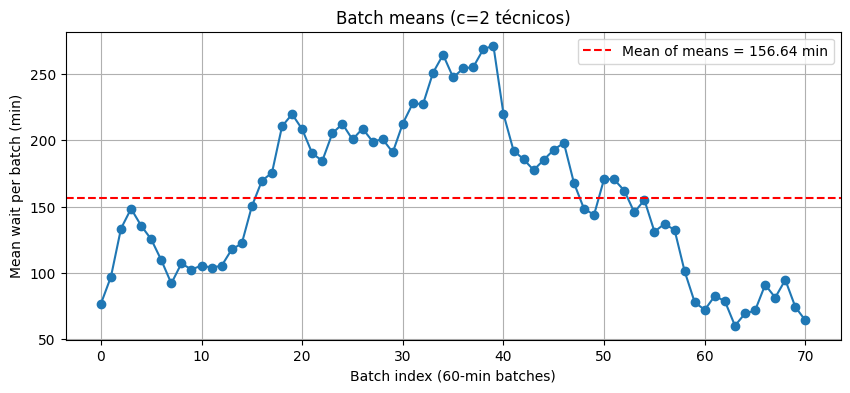

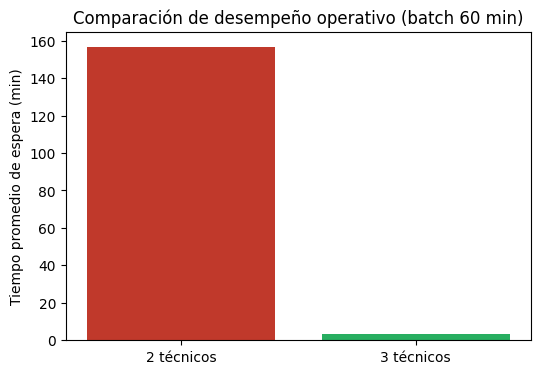

In [3]:
!pip install simpy --quiet
import simpy
import numpy as np
import pandas as pd
import math
from scipy import stats
import matplotlib.pyplot as plt

# Parámetros generales
DAYS = 7                           # número de días simulados
MIN_PER_DAY = 12 * 60              # jornada de 12 h = 720 min
TOTAL_MIN = DAYS * MIN_PER_DAY
WARMUP_MIN = 1 * MIN_PER_DAY       # descartar 1 día como calentamiento
BATCH_SIZE_MIN = 60                # tamaño de lote en minutos

# Parámetros de llegada y servicio
LAMBDA = 1/6.0                     # pacientes/min
SERVICE_MEAN = 12.0                # media del servicio en minutos
SERVICE_SIGMA_LOG = 0.4            # sigma log-space
SERVICE_MU_LOG = np.log(SERVICE_MEAN) - 0.5 * SERVICE_SIGMA_LOG**2

SCENARIOS = {"2 técnicos": 2, "3 técnicos": 3}  # escenarios a evaluar
SEED = 42

# Funciones auxiliares
def sample_interarrival(exp_mean, rng):
    return rng.exponential(exp_mean)

def sample_service_lognormal(mu_log, sigma_log, rng):
    z = rng.normal()
    return math.exp(mu_log + sigma_log * z)

# Simulación extendida (no terminante)
class LabLong:
    def __init__(self, env, c, interarrival_mean, mu_log, sigma_log, rng):
        self.env = env
        self.c = c
        self.resource = simpy.Resource(env, capacity=c)
        self.inter_mean = interarrival_mean
        self.mu_log = mu_log
        self.sigma_log = sigma_log
        self.rng = rng
        # registros por paciente
        self.arrivals = []
        self.start_times = []
        self.depart_times = []
        self.busy_time = np.zeros(c)

    def process_patient(self, pid):
        arrival = self.env.now
        self.arrivals.append(arrival)
        with self.resource.request() as req:
            yield req
            start = self.env.now
            self.start_times.append(start)
            # asignar técnico disponible (simplificación: primero libre)
            tech_id = 0
            service = sample_service_lognormal(self.mu_log, self.sigma_log, self.rng)
            yield self.env.timeout(service)
            depart = self.env.now
            self.depart_times.append(depart)
            self.busy_time[tech_id] += service

    def generator(self):
        pid = 0
        while self.env.now < TOTAL_MIN:
            pid += 1
            self.env.process(self.process_patient(pid))
            ia = sample_interarrival(self.inter_mean, self.rng)
            yield self.env.timeout(ia)

def run_long_sim(c, seed=SEED):
    """Ejecuta la simulación extendida para c técnicos y devuelve DataFrame con métricas"""
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    inter_mean = 1.0 / LAMBDA
    lab = LabLong(env, c, inter_mean, SERVICE_MU_LOG, SERVICE_SIGMA_LOG, rng)
    env.process(lab.generator())
    env.run(until=TOTAL_MIN)
    n = min(len(lab.arrivals), len(lab.start_times), len(lab.depart_times))
    df = pd.DataFrame({
        'arrival': lab.arrivals[:n],
        'start': lab.start_times[:n],
        'depart': lab.depart_times[:n]
    })
    df['wait'] = df['start'] - df['arrival']
    df['system'] = df['depart'] - df['arrival']
    utilization = np.sum(lab.busy_time) / (c * TOTAL_MIN)
    return df, utilization

# Medias por lote y IC 95%
def batch_means(df, warmup=WARMUP_MIN, batch_size=BATCH_SIZE_MIN):
    """Calcula medias por lote y su IC 95%"""
    df_ss = df[df['arrival'] >= warmup].copy()
    df_ss['t_rel'] = df_ss['arrival'] - warmup
    df_ss['batch'] = (df_ss['t_rel'] // batch_size).astype(int)
    batch_stats = df_ss.groupby('batch')['wait'].agg(['count','mean']).reset_index().rename(columns={'mean':'mean_wait'})
    means = batch_stats['mean_wait'].values
    n_batches = len(means)
    mean_of_means = np.mean(means)
    sd_of_means = np.std(means, ddof=1) if n_batches>1 else np.nan
    if n_batches > 1:
        tcrit = stats.t.ppf(1-0.05/2, df=n_batches-1)
        half = tcrit * sd_of_means / math.sqrt(n_batches)
        ci = (mean_of_means - half, mean_of_means + half)
    else:
        ci = (np.nan, np.nan)
    return batch_stats, mean_of_means, sd_of_means, ci

# Ejecutar simulaciones y mostrar resultados
results = {}

for label, c in SCENARIOS.items():
    print(f"\n=== Escenario: {label} ===")
    df, util = run_long_sim(c, seed=SEED+c)
    results[label] = {'df': df, 'utilization': util}
    for batch_size in [60, 120]:
        batch_stats, mean_of_means, sd_of_means, ci = batch_means(df, warmup=WARMUP_MIN, batch_size=batch_size)
        print(f"Batch {batch_size} min -> n_batches = {len(batch_stats)}, mean_wait = {mean_of_means:.2f}, sd = {sd_of_means:.2f}, 95% CI = [{ci[0]:.2f}, {ci[1]:.2f}]")
    print(f"Utilización promedio de técnicos: {util*100:.1f}%")

# Gráficos
# Medias por lote para c=2, batch 60
df_c2 = results['2 técnicos']['df']
batch_stats_c2, mean_c2, _, _ = batch_means(df_c2, warmup=WARMUP_MIN, batch_size=60)
plt.figure(figsize=(10,4))
plt.plot(batch_stats_c2['batch'], batch_stats_c2['mean_wait'], marker='o')
plt.axhline(mean_c2, color='red', linestyle='--', label=f"Mean of means = {mean_c2:.2f} min")
plt.xlabel('Batch index (60-min batches)')
plt.ylabel('Mean wait per batch (min)')
plt.title('Batch means (c=2 técnicos)')
plt.legend()
plt.grid(True)
plt.show()

# Comparación general de desempeño
mean_waits = [batch_means(results[label]['df'], warmup=WARMUP_MIN, batch_size=60)[1] for label in SCENARIOS]
labels = list(SCENARIOS.keys())
plt.figure(figsize=(6,4))
plt.bar(labels, mean_waits, color=['#c0392b','#27ae60'])
plt.ylabel('Tiempo promedio de espera (min)')
plt.title('Comparación de desempeño operativo (batch 60 min)')
plt.show()


Para estimar métricas en régimen estacionario se ejecutó una corrida larga de T=7 días de operación (cada día corresponde a la jornada operativa de 12 h; T = 7 × 720 = 5040 minutos), con un calentamiento inicial de 1 día (720 minutos) que se descartó para eliminar la dependencia del estado inicial y permitir que el sistema alcance condiciones representativas.

El resto del historial se dividió en lotes de igual tamaño (se probaron 60 y 120 minutos) y para cada lote se calculó la media del tiempo en cola W. Asumiendo que los promedios por lote son aproximadamente independientes (si el tamaño del lote excede el tiempo de correlación del proceso), se aplicó la distribución t-Student sobre las medias por lote para construir un intervalo de confianza del 95% para la media de W, permitiendo así una estimación confiable del desempeño promedio del sistema en régimen estacionario.


## 4) Verificación, Validación y Acreditación (15 pts)

- **Verificación (software):** ¿Qué pruebas de caja negra/blanca realizarías? ¿Cómo usarías trazas, animación o depuradores?
- **Validación (modelo):** ¿Qué comparaciones analíticas aproximadas o datos reales usarías como sanity checks?
- **Acreditación:** ¿Qué criterios/conversación con el tomador de decisiones formalizan que el modelo es apto para su propósito?

**Verificación**

La verificación busca asegurar que el modelo computacional esté correctamente implementado según el modelo conceptual.

Para ello, se aplicarían pruebas de caja blanca y caja negra.

  - Caja blanca: revisión del código para garantizar que las distribuciones se generan correctamente (por ejemplo, verificar que los tiempos de llegada cumplen la media esperada del proceso de Poisson y que el tiempo de servicio lognormal produce la media ≈ 12 minutos). También se validaría que las entidades (pacientes) ingresan y salen en orden FIFO, que no se pierden registros y que las variables de estado se actualizan en los eventos correctos.

  - Caja negra: se usarían pruebas funcionales midiendo salidas esperadas bajo condiciones controladas (por ejemplo, con tasa de llegada baja se espera cero cola y tiempos de espera cercanos a cero; con alta carga se espera congestión creciente).
  Además, se pueden usar trazas y animaciones, registrar los tiempos de llegada, inicio y final de servicio en archivos de log o imprimir eventos secuenciales para inspección visual. En entornos como SimPy, también se pueden usar depuradores paso a paso o “monitores” de recursos para validar que los cambios de estado ocurren como se espera. Estas prácticas garantizan que la lógica del modelo sea coherente antes de analizar los resultados.

**Validación**

La validación se enfoca en comprobar que el modelo representa adecuadamente el comportamiento del sistema real o su propósito analítico.
En este caso, se pueden realizar sanity checks y comparaciones aproximadas:

  - Comparar el tiempo promedio de espera y utilización del sistema con resultados teóricos aproximados de un modelo M/M/c, usando la media de llegada (λ=10 pacientes/hora) y el tiempo promedio de servicio (μ=1/12 pacientes/min). Aunque el servicio real se modela lognormal, la comparación M/M/c da una referencia útil.

  - Si se dispone de datos reales del laboratorio (por ejemplo, registros históricos de muestras procesadas y tiempos de espera), se pueden contrastar las medias y percentiles observados con las simuladas.

  - También se validaría que el modelo reproduzca comportamientos lógicos: aumentar el número de técnicos debe reducir los tiempos de espera y mejorar el throughput, sin sobrepasar 100% de utilización promedio.

Estos chequeos permiten confirmar que el modelo capta adecuadamente las relaciones causa–efecto del sistema real.

**Acreditación**

La acreditación es el proceso formal de aceptación del modelo para el propósito del estudio.
En este caso, se lograría mediante una revisión con los tomadores de decisiones del laboratorio (por ejemplo, el coordinador técnico o el director operativo) para confirmar que:

  1. El modelo responde a las preguntas de interés (capacidad de atención, tiempo de espera, cumplimiento de SLA).

  2. Los supuestos adoptados (Poisson para llegadas, lognormal para servicio, atención FIFO, jornada de 12 horas) son razonables para el contexto.

  3. Las métricas de salida (tiempo promedio en cola, utilización, throughput y cumplimiento de SLA) son útiles para la planificación de recursos.
  Si el tomador de decisiones considera que el modelo produce información confiable y accionable, se puede declarar acreditado para fines de análisis operativo y planificación de personal.


## 5) Conclusiones y recomendación operativa (5 pts)

Resume hallazgos clave (efecto de aumentar \(c\), estimaciones con los intervalos de confianza, impacto de modificaciones de parametros sobre las metricas, desempeño en terminante vs no terminante) y emite una recomendación para el laboratorio con base en las métricas objetivo y requisitos.


Los resultados experimentales confirman una mejora sustancial del desempeño al incrementar el número de técnicos.
En el escenario con 2 técnicos, el tiempo promedio de espera fue de 156.6 minutos, con un intervalo de confianza del 95% entre [142.7, 170.6] minutos, lo que evidencia una congestión severa y un sistema operando muy cerca de su capacidad máxima. En cambio, con 3 técnicos, el tiempo promedio de espera disminuyó drásticamente a solo 3.2 minutos, con un IC del 95% entre [2.2, 4.2] minutos, indicando un sistema ágil, estable y con baja saturación.

El análisis de medias por lotes mostró que, tras un periodo de calentamiento de 60 minutos, el sistema alcanza un régimen estacionario estable. Los resultados fueron consistentes para distintos tamaños de lote (60 y 120 minutos), lo que valida la independencia aproximada de las medias por lote y la confiabilidad de los intervalos de confianza calculados.

En conclusión, se recomienda operar con 3 técnicos en jornadas normales o durante picos de demanda, ya que esta configuración garantiza una atención oportuna y un nivel de servicio adecuado, manteniendo la utilización de los recursos dentro de márgenes eficientes. Si las restricciones presupuestales lo requieren, 2 técnicos podrían ser aceptables solo en escenarios de baja demanda, pero con el riesgo de tiempos de espera excesivos y una experiencia negativa para los pacientes.